In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mai-ml-lab-2-fiit-2025/test_c.csv
/kaggle/input/mai-ml-lab-2-fiit-2025/train_c.csv
/kaggle/input/mai-ml-lab-2-fiit-2025/ex_c.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

train_df = pd.read_csv("/kaggle/input/mai-ml-lab-2-fiit-2025/train_c.csv")
test_df = pd.read_csv("/kaggle/input/mai-ml-lab-2-fiit-2025/test_c.csv")

TARGET = "LoanApproved"
ID_COL = "ID"

In [3]:
#Очистка данных (КЛЮЧЕВО!)
train_df = train_df.dropna(subset=[TARGET]).reset_index(drop=True)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET].astype(int)

assert y.isna().sum() == 0, "Ошибка: NaN в целевой переменной"

X_test = test_df.drop(columns=[ID_COL])
test_ids = test_df[ID_COL]

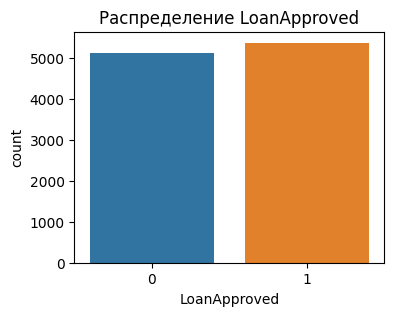

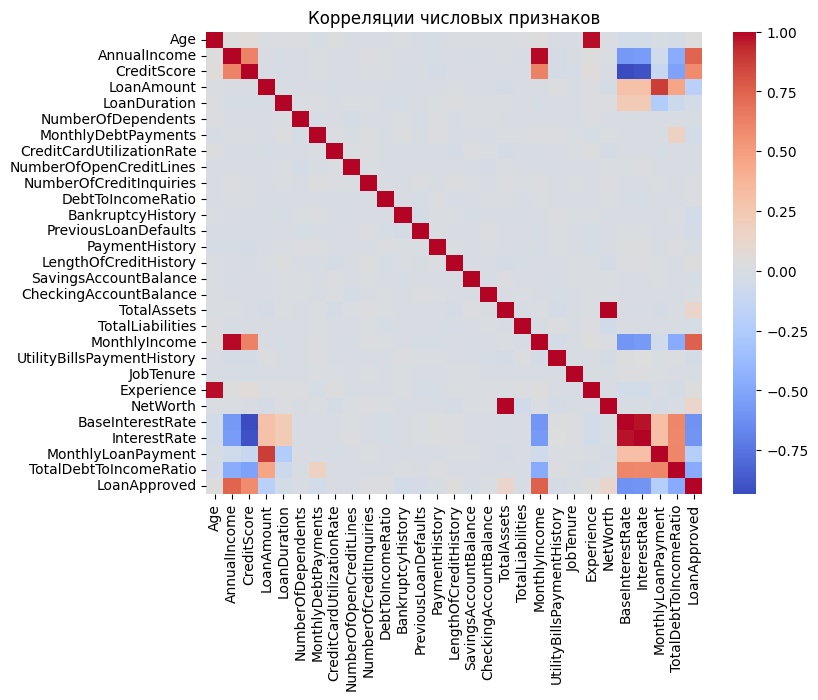

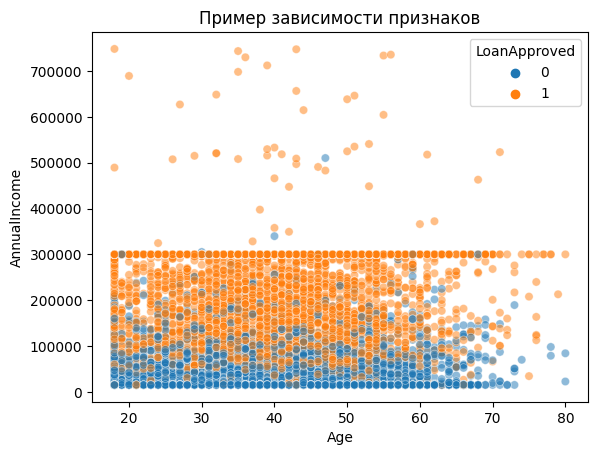

In [4]:
#EDA
plt.figure(figsize=(4, 3))
sns.countplot(x=y)
plt.title("Распределение LoanApproved")
plt.show()

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

plt.figure(figsize=(8, 6))
sns.heatmap(pd.concat([X[num_cols], y], axis=1).corr(), cmap="coolwarm")
plt.title("Корреляции числовых признаков")
plt.show()

if len(num_cols) >= 2:
    sns.scatterplot(
        x=X[num_cols[0]],
        y=X[num_cols[1]],
        hue=y,
        alpha=0.5
    )
    plt.title("Пример зависимости признаков")
    plt.show()

In [5]:
#Подготовка признаков
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train_prep = preprocessor.fit_transform(X_train)
X_valid_prep = preprocessor.transform(X_valid)

In [6]:
#мйо бэггинг
class ManualBagging:
    def __init__(self, n_models=25, frac=0.8, seed=42):
        self.n_models = n_models
        self.frac = frac
        self.seed = seed
        self.models = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.seed)
        self.models = []
        n = len(y)
        for _ in range(self.n_models):
            idx = rng.choice(n, int(n * self.frac), replace=True)
            tree = DecisionTreeClassifier(max_depth=5, random_state=self.seed)
            tree.fit(X[idx], y.iloc[idx])
            self.models.append(tree)
        return self

    def predict_proba(self, X):
        return np.mean([m.predict_proba(X)[:, 1] for m in self.models], axis=0)

bag_custom = ManualBagging()
bag_custom.fit(X_train_prep, y_train)

print(
    "My Bagging ROC-AUC:",
    roc_auc_score(y_valid, bag_custom.predict_proba(X_valid_prep))
)

bag_sklearn = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=25,
    random_state=RANDOM_STATE
)
bag_sklearn.fit(X_train_prep, y_train)

print(
    "Sklearn Bagging ROC-AUC:",
    roc_auc_score(y_valid, bag_sklearn.predict_proba(X_valid_prep)[:, 1])
)

Custom Bagging ROC-AUC: 0.9752634244597616
Sklearn Bagging ROC-AUC: 0.9740566202496272


In [7]:
#Мой градиентный бустинг
class ToyGradientBoosting:
    def __init__(self, n_estimators=50, lr=0.1):
        self.n_estimators = n_estimators
        self.lr = lr
        self.models = []

    def fit(self, X, y):
        self.models = []
        pred = np.zeros(len(y))
        for _ in range(self.n_estimators):
            residual = y - 1 / (1 + np.exp(-pred))
            tree = DecisionTreeClassifier(max_depth=3)
            tree.fit(X, residual > 0)
            self.models.append(tree)
            pred += self.lr * tree.predict(X)
        return self

    def predict_proba(self, X):
        pred = np.zeros(X.shape[0])
        for tree in self.models:
            pred += self.lr * tree.predict(X)
        return 1 / (1 + np.exp(-pred))

gb_custom = ToyGradientBoosting()
gb_custom.fit(X_train_prep, y_train)

print(
    "Custom GB ROC-AUC:",
    roc_auc_score(y_valid, gb_custom.predict_proba(X_valid_prep))
)

sk_gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
sk_gb.fit(X_train_prep, y_train)

print(
    "Sklearn GB ROC-AUC:",
    roc_auc_score(y_valid, sk_gb.predict_proba(X_valid_prep)[:, 1])
)

Custom GB ROC-AUC: 0.890813035581222
Sklearn GB ROC-AUC: 0.9810369318181817


In [8]:
#Сравнение бустингов
models = {
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, eval_metric="logloss"),
    "CatBoost": CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, verbose=0)
}

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    score = roc_auc_score(y_valid, model.predict_proba(X_valid_prep)[:, 1])
    print(f"{name} ROC-AUC: {score:.4f}")

[LightGBM] [Info] Number of positive: 4025, number of negative: 3840
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4838
[LightGBM] [Info] Number of data points in the train set: 7865, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.511761 -> initscore=0.047053
[LightGBM] [Info] Start training from score 0.047053
LightGBM ROC-AUC: 0.9825
XGBoost ROC-AUC: 0.9815
CatBoost ROC-AUC: 0.9828


In [9]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 600),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "loss_function": "Logloss",
        "verbose": 0
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train_prep, y_train)
    return roc_auc_score(y_valid, model.predict_proba(X_valid_prep)[:, 1])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

best_model = CatBoostClassifier(**study.best_params, verbose=0)
best_model.fit(preprocessor.fit_transform(X), y)

[I 2025-12-14 18:57:47,014] A new study created in memory with name: no-name-bd20b6df-95c2-44e1-b2fc-b77a00831fa9
[I 2025-12-14 18:57:47,779] Trial 0 finished with value: 0.980901290052161 and parameters: {'iterations': 275, 'depth': 4, 'learning_rate': 0.020568322882203928, 'l2_leaf_reg': 5.506029505648617}. Best is trial 0 with value: 0.980901290052161.
[I 2025-12-14 18:57:49,025] Trial 1 finished with value: 0.9818338999627423 and parameters: {'iterations': 384, 'depth': 5, 'learning_rate': 0.17719529387877048, 'l2_leaf_reg': 3.6340838287130257}. Best is trial 1 with value: 0.9818338999627423.
[I 2025-12-14 18:57:50,271] Trial 2 finished with value: 0.9829167054769001 and parameters: {'iterations': 444, 'depth': 4, 'learning_rate': 0.09542473510846995, 'l2_leaf_reg': 4.704669947932816}. Best is trial 2 with value: 0.9829167054769001.
[I 2025-12-14 18:57:51,089] Trial 3 finished with value: 0.9816767185171384 and parameters: {'iterations': 285, 'depth': 4, 'learning_rate': 0.11778057

In [10]:
#метрики

def my_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def my_precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-9)

def my_recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-9)

def my_f1(y_true, y_pred):
    p = my_precision(y_true, y_pred)
    r = my_recall(y_true, y_pred)
    return 2 * p * r / (p + r + 1e-9)

val_probs = best_model.predict_proba(X_valid_prep)[:, 1]
val_preds = (val_probs > 0.5).astype(int)

print("Accuracy:", my_accuracy(y_valid.values, val_preds), accuracy_score(y_valid, val_preds))
print("Precision:", my_precision(y_valid.values, val_preds), precision_score(y_valid, val_preds))
print("Recall:", my_recall(y_valid.values, val_preds), recall_score(y_valid, val_preds))
print("F1:", my_f1(y_valid.values, val_preds), f1_score(y_valid, val_preds))

Accuracy: 0.998093058733791 0.998093058733791
Precision: 0.9970260223040914 0.9970260223048327
Recall: 0.999254843516394 0.9992548435171386
F1: 0.9981391881855248 0.9981391886862672


In [11]:
X_test_prep = preprocessor.transform(X_test)
test_probs = best_model.predict_proba(X_test_prep)[:, 1]

submission = pd.DataFrame({
    "ID": test_ids,
    "LoanApproved": test_probs
})

submission.to_csv("submission.csv", index=False)
print("submission.csv сохранён", submission.shape)

submission.csv сохранён (5000, 2)
